In [3]:
import matplotlib as mpl
%matplotlib inline
# Set the font to Times New Roman or a similar serif font
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
# Adjust the text sizes
mpl.rcParams['axes.labelsize'] = 10  # For X and Y axis labels
mpl.rcParams['axes.titlesize'] = 10  # For the plot title
mpl.rcParams['legend.fontsize'] = 10 # For the legend


from utils import *

colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]

In [7]:
def plot_husimi_probability_contours(dressed_state,product_to_dressed,qubit_level,osc_level):
    if dressed_state.dims[-1][0] == 1:
        dressed_state = qutip.ket2dm(dressed_state)
    dressed_dm_data = dressed_state.full()
    rho_product = np.zeros((qubit_level * osc_level, qubit_level * osc_level), dtype=complex)
    for (ql, ol), dressed_level in product_to_dressed.items():
        index1 = ql * osc_level + ol
        # Loop again to populate the density matrix
        for (ql2, ol2), dressed_level2 in product_to_dressed.items():
            index2 = ql2 * osc_level + ol2
            # TODO  the order of product_state and product_state2 doesn't make sense to me, but it produces the right result. :(
            element = dressed_dm_data[dressed_level, dressed_level2]
            rho_product[index1, index2] += element
    rho_product = qutip.Qobj(rho_product, dims=[[qubit_level, osc_level], [qubit_level, osc_level]])
    rho_coherent = rho_product.ptrace(1)

    # print(f"nonhermicity: abs(rho_coherent - rho_coherent.dag()).data.max() {abs(rho_coherent - rho_coherent.dag()).data.max()}")
    # print(f"nonhermicity: Frobenius norm of the difference between rho and rho dag {np.linalg.norm((rho_coherent - rho_coherent.dag()).full(), 'fro')}")
    rho_coherent = 0.5 * (rho_coherent + rho_coherent.dag())

    # print(f"trace: {rho_coherent.tr()}")
    rho_coherent = rho_coherent / rho_coherent.tr()


    xvec = np.linspace(-20,20,500)

    Q_coherent = qutip.qfunc(rho_coherent, xvec, xvec)

    q_values = Q_coherent
    sorted_q = np.sort(q_values.ravel())
    cumulative_sum = np.cumsum(sorted_q)
    total_sum = cumulative_sum[-1]
    X, Y = np.meshgrid(xvec, xvec)
    # for prob in [0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.05,0.02]:
    for prob in [0.9,0.7,0.5]:
        level_value = sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - prob))]
        contour = plt.contour(X, Y, q_values, levels=[level_value], colors=[(prob, 0, 0, 1)])
        fmt = {level_value:f'{1 - prob:.2f}'}
        plt.clabel(contour, inline=False, fontsize=6, fmt=fmt)

    # Q_coherent[Q_coherent < sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - 0.98))]] = None
    # plt.contourf(xvec, xvec, Q_coherent, 100)
        


def compute_contrast(results, res_idx1,res_idx2,# Which two results to compute contrast between
                     kappa, # in GHz
                     w_d,tlist,
                     fourier):

    alphas = []
    for i in [res_idx1,res_idx2]:
        alphas.append(results[i].expect[0])

    if fourier == True:
        first_dominant_freq =find_dominant_frequency(alphas[0],tlist)
    else:
        first_dominant_freq = w_d

    alphas[0] = alphas[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alphas[1] = alphas[1]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)


    # Step-2 do integration
    squared_diff = np.square(abs(alphas[0]-alphas[1]))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                         (tlist[i]-tlist[i-1])*np.sqrt(kappa)*squared_diff[i]
                         )
        
    photon_counting_contrast = [0.0]
    for i in range(1,len(tlist)):
        photon_counting_contrast.append(photon_counting_contrast[i-1]+
                         (tlist[i]-tlist[i-1])*kappa*squared_diff[i]
                         )
        
    # Step-3 Plot
    plt.plot(tlist, integrals, label='I-Q contrast',color= 'black')
    plt.plot(tlist, photon_counting_contrast, label='photon counting contrast',color= 'grey',linestyle= ':')

    # plt.plot(tlist, squared_diff, label='Squared Difference')
    plt.yscale('log')
    plt.yticks([0.1,1, 2, 3, 4, 5, 6, 7, 8, 9, 10,100])
    plt.legend()
    plt.grid()
    # plt.show()
    # return integrals

 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_38752/1234123265.py: 133

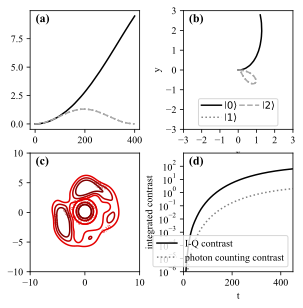

In [8]:
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.4))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1,1], wspace=0.4)


tot_time =450
t_stop = 400
tlist = np.linspace(0, tot_time, tot_time)
qubit_level = 25
osc_level = 40
system = fluxonium_oscillator_system(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = 7.17391479,
    g_strength = 0.13,
    qubit_level = qubit_level,
    osc_level = osc_level,
    kappa = 1e-3,
    products_to_keep=[[ql, ol] for ql in [2] for ol in range(3) ],
    computaional_states = '1,2',
    )

all_results = []
for i in range(5):
    with open(f'pickles/mcsolve_2.65_g0.13_a0.003_10level_qbt_state{i}_summed_padd_back.pkl', 'rb') as file:
        result = pickle.load(file)
    all_results.append(result)
results = [all_results[0],all_results[1],all_results[2]]


detection_results_1em3 = [results[0],results[1],results[2]]
first_dominant_freq =find_dominant_frequency(results[1].expect[0],tlist)


################################################################################
#
#
# Photon number
#
#
#################################################################################
ax = plt.subplot(gs[0,0])
plt.text(0.05, 0.97, '(a)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
for i, linestype,color in zip([0,1,2],['-',':','--'],['black','gray','darkgrey']):
    plt.plot(tlist[:t_stop], 
             results[i].expect[-1][:t_stop], 
            label=r"$\langle\hat{a}^{\dagger}\hat{a}\rangle$",
            color = color,
            linestyle = linestype)


################################################################################
#
#
# Coherent state
#
#
#################################################################################
ax = plt.subplot(gs[0,1])
plt.text(0.05, 0.97, '(b)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
for i, linestype,color in zip([0,1,2],['-',':','--'],['black','gray','darkgrey']):
    alpha = all_results[i].expect[-2][:t_stop]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist[:t_stop])
    ax.plot(-alpha.imag,alpha.real,color=color,linestyle=linestype,label = rf'$\left|{i}\right>$')

ax.set_xlim(-1,3)
ax.set_ylim(-1,3)
    

ax.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, 0.3), 
    ncol=2, 
    frameon=True, 
    borderpad=0.3,  # Padding inside the border, smaller value = tighter packing
    handletextpad=0.3,  # Padding between the legend handle and text
    labelspacing=0.3,   # Vertical spacing between the labels
    columnspacing = 0.2
)
ax.set_xticks([-3,-2,-1,0,1,2,3])
ax.set_yticks([-3,-2,-1,0,1,2,3])
ax.set_xlabel('x')
ax.set_ylabel('y')



################################################################################
#
#
# Husimi
#
#
#################################################################################
ax = plt.subplot(gs[1,0])
plt.text(0.05, 0.97, '(c)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
for i in [0,1,2]:
    val = plot_husimi_probability_contours(dressed_state=detection_results_1em3[i].states[400],
                                    product_to_dressed=system.product_to_dressed,
                                    qubit_level = qubit_level,
                                    osc_level = osc_level,
                                    )

ax.set_xlim(-10,10)
ax.set_ylim(-10,10)


################################################################################
#
#
# Contrast
#
#
#################################################################################
ax = plt.subplot(gs[1,1])
plt.text(0.05, 0.97, '(d)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
compute_contrast(results = results, 
                 res_idx1= 0, 
                 res_idx2 = 1,
                kappa = 1e-3,
                w_d = 7.17391479,
                tlist = results[0].times,
                fourier = True)

ax.legend(loc='lower right')
ax.set_yscale('log')
ax.set_ylim(1e-4,1e3)
ax.set_yticks([1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
ax.set_xlim(0,tot_time)
ax.grid()
ax.set_xlabel('t')
ax.set_ylabel('integrated contrast')

plt.tight_layout()
plt.savefig('fig04_coherentstate_contrast_leakage_fidelity.pdf', format='pdf', bbox_inches='tight')

plt.show()

Text(0.5, -7.00277777777778, 'ns')

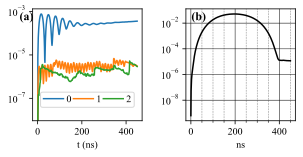

In [10]:
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*0.6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.4)

ax = plt.subplot(gs[0,0])
plt.text(-0.12, 0.97, '(a)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
with open('pickles/mcsolve_g0.13_a0.003_leakage_list.pkl', 'rb') as file:
    lists = pickle.load(file)
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, 0.3), 
    ncol=3, 
    frameon=True, 
    borderpad=0.3,  # Padding inside the border, smaller value = tighter packing
    handletextpad=0.3,  # Padding between the legend handle and text
    labelspacing=0.3,   # Vertical spacing between the labels
    columnspacing = 0.2
)
# plt.title('expecation of qubit not being in initial state, sesolve with 15 level qbt, 40 level osc')
plt.xlabel('t (ns)')



ax = plt.subplot(gs[0,1])
plt.text(0.05, 0.97, '(b)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
all_results = []
for i in range(5):
    with open(f'pickles/mcsolve_2.65_g0.13_a0.003_10level_qbt_state{i}_summed_two_level.pkl', 'rb') as file:
        result = pickle.load(file)
    all_results.append(result)
results = [all_results[1],all_results[2],all_results[3],all_results[4]]
num_time_steps = 450
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]

def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(gate*dm*gate.dag(), dm_ideal))
    return 1-sum(fid)/len(fid)
from scipy.optimize import minimize
infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [result.states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])

with open(f'pickles/mcsolve_2.65_g0.13_a0.003_kappa_1e-3_phase.pkl', 'wb') as file:
    pickle.dump(phase, file)




plt.plot(results[0].times,infidelity,color='black')
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.savefig('fig05_additional_leakage_and_fidelity.pdf', format='pdf', bbox_inches='tight')
plt.xlabel("ns")